In [ ]:
# Encodando os atributos com valores em string

df_pt['Sexo'] = df_pt['Sexo'].map({'M': 0, 'F': 1})
df_pt['AnginaExercicio'] = df_pt['AnginaExercicio'].map({'Y': 1, 'N': 0})

# Os tipos de dores no peito estão classificados como Qualit. Nominal, porém, de acordo com a literatura
# cada tipo de dor implica num nível de agravante maior, logo, é ORDINAL.
df_pt['TipoDorPeito'] = df_pt['TipoDorPeito'].map({'TA': 3, 'ATA': 2, 'NAP': 1, 'ASY': 0})
df_pt['ECGRepouso'] = df_pt['ECGRepouso'].map({'Normal': 0, 'ST': 1, 'LVH': 2})

# Para a inclinação do pico do segmento da onda ST do eletrocardiograma durante exercício, também temos uma ordem de agravante
# Onde as chances da pessoa estar doente com ST ascendente são as menores dentre todas, seguidas da descendente, com chances
# maiores e, por fim, a plana, que é a que apresenta a maior quantidade de pacientes com insuficiência cardíaca
df_pt['InclinacaoST'] = df_pt['InclinacaoST'].map({'Up': 0, 'Down': 1, 'Flat': 2})

df_pt.head(11)

,Idade,Sexo,TipoDorPeito,PressaoArterialRepouso,Colesterol,GlicoseJejum,ECGRepouso,FrequenciaCardiacaMaxima,AnginaExercicio,Oldpeak,InclinacaoST,DoencaCardiaca
0,40,0,2,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,2,1
2,37,0,2,130,283,0,1,98,0,0.0,0,0
3,48,1,0,138,214,0,0,108,1,1.5,2,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0
5,39,0,1,120,339,0,0,170,0,0.0,0,0
6,45,1,2,130,237,0,0,170,0,0.0,0,0
7,54,0,2,110,208,0,0,142,0,0.0,0,0
8,37,0,0,140,207,0,0,130,1,1.5,2,1
9,48,1,2,120,284,0,0,120,0,0.0,0,0


/tmp/ipython-input-396803543.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


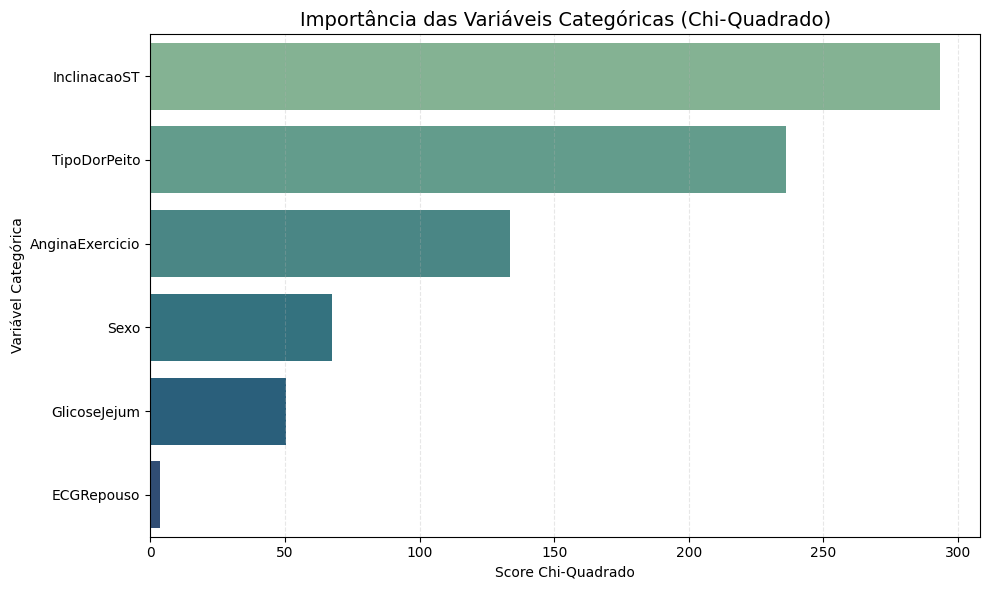

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#Geração do gráfico dos resultados das variáveis categóricas
plt.figure(figsize=(10, 6))
sns.barplot(
    x=cat_df['Chi-Quadrado'],
    y=cat_df.index,
    palette="crest"
)
plt.title("Importância das Variáveis Categóricas (Chi-Quadrado)", fontsize=14)
plt.xlabel("Score Chi-Quadrado")
plt.ylabel("Variável Categórica")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

Após criação dos gráficos, podemos verificar que a feature mais relavante, entre as categóricas, é a InclinacaoST.

/tmp/ipython-input-104481853.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


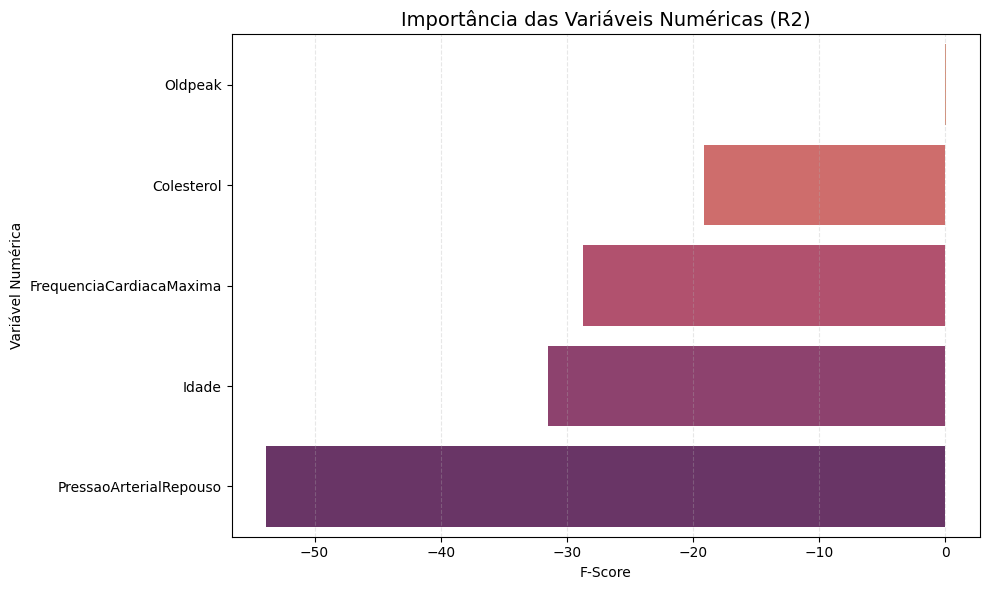

In [ ]:
#Geração do gráfico dos resultados das variáveis numéricas
plt.figure(figsize=(10, 6))
sns.barplot(
    x=num_df['R2'],
    y=num_df.index,
    palette="flare"
)
plt.title("Importância das Variáveis Numéricas (R2)", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Variável Numérica")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

Ao utilizar o coeficiente de determinação (R²), observamos que ele não é adequado para o caso em questão, pois não permite a comparação entre variáveis numéricas e categóricas. Para esse tipo de análise, o método mais apropriado é o Teste F, disponível na biblioteca Scikit-Learn (f_classif), que permite avaliar a relação entre variáveis categóricas e o alvo da classificação.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

#Separação do target, variáveis categóricas e numéricas
target = df_pt['DoencaCardiaca']
cat_df = df_pt.drop(columns=['Idade', 'PressaoArterialRepouso', 'Colesterol', 'FrequenciaCardiacaMaxima', 'Oldpeak', 'DoencaCardiaca'])
num_df = df_pt.drop(columns=['Sexo','TipoDorPeito','GlicoseJejum','ECGRepouso','AnginaExercicio','InclinacaoST','DoencaCardiaca'])

#Aplicação do SelectKBest para variáveis:
#Numéricas (f-score)
best_num = SelectKBest(f_classif, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
num_df = pd.DataFrame(num_scores, index=num_df.columns, columns=['F_Score'])
#Ordenando do maior para o menor
num_df = num_df.sort_values(by='F_Score', ascending=False)
#Printando resultados
display(num_df)

,F_Score
Oldpeak,178.615120
FrequenciaCardiacaMaxima,174.913585
Idade,79.160779
PressaoArterialRepouso,12.889725
Colesterol,0.826763


/tmp/ipython-input-562313287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


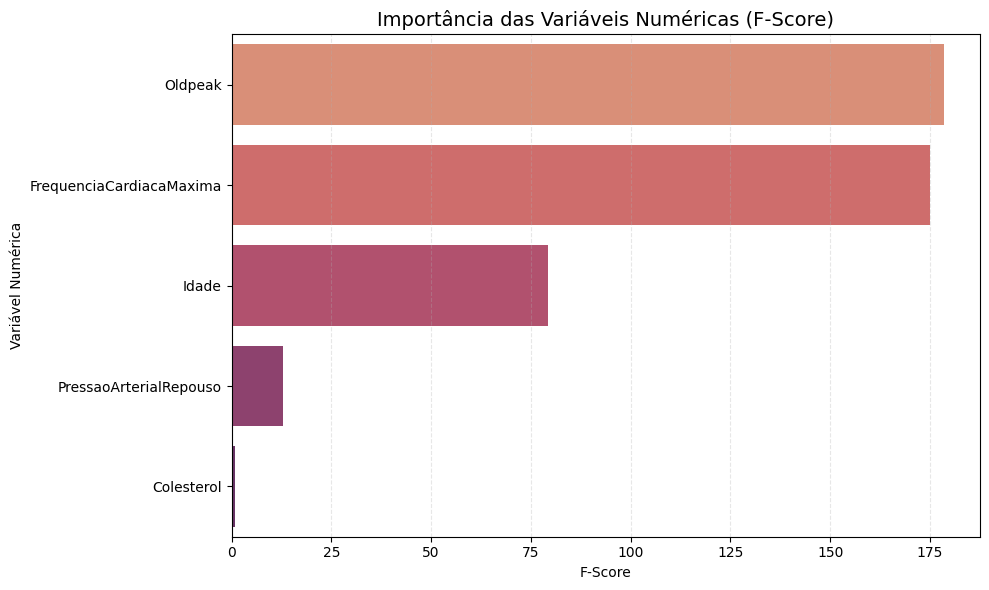

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=num_df['F_Score'],
    y=num_df.index,
    palette="flare"
)
plt.title("Importância das Variáveis Numéricas (F-Score)", fontsize=14)
plt.xlabel("F-Score")
plt.ylabel("Variável Numérica")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

Após correção, podemos verificar que a feature mais relavante, entre as numéricas, é a OldPeak.

#####################################################################################################

#####################################################################################################

#####################################################################################################

# Trabalho Final

### Base de Dados: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

In [1]:
!pip install ucimlrepo

In [3]:
#Ignorar warning
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

In [4]:
from ucimlrepo import fetch_ucirepo

#Consulta da Base
default_of_credit_card_clients = fetch_ucirepo(id=350)

#Separação de features e target
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

In [5]:
import pandas as pd

#Unindo features e target
df_features = pd.DataFrame(X)
df_target = pd.DataFrame(y)
df = pd.concat([df_features, df_target], axis=1)

In [6]:
#Renomeando colunas
cols_features = {
    "X1":  "valor_credito",
    "X2":  "sexo",
    "X3":  "educacao",
    "X4":  "estado_civil",
    "X5":  "idade_anos",
    "X6":  "status_pag_set_2005",
    "X7":  "status_pag_ago_2005",
    "X8":  "status_pag_jul_2005",
    "X9":  "status_pag_jun_2005",
    "X10": "status_pag_mai_2005",
    "X11": "status_pag_abr_2005",
    "X12": "valor_fatura_set_2005",
    "X13": "valor_fatura_ago_2005",
    "X14": "valor_fatura_jul_2005",
    "X15": "valor_fatura_jun_2005",
    "X16": "valor_fatura_mai_2005",
    "X17": "valor_fatura_abr_2005",
    "X18": "valor_pago_set_2005",
    "X19": "valor_pago_ago_2005",
    "X20": "valor_pago_jul_2005",
    "X21": "valor_pago_jun_2005",
    "X22": "valor_pago_mai_2005",
    "X23": "valor_pago_abr_2005"
}
col_target = {
    "Y": "inadimplente"
}

#Aplicação do rename:
df_features.rename(columns=cols_features, inplace=True)
df_target.rename(columns=col_target, inplace=True)

In [7]:
#Criação de novas features a partir das colunas status_pag_MÊS_ANO

status_pag_cols = [
    'status_pag_set_2005',
    'status_pag_ago_2005',
    'status_pag_jul_2005',
    'status_pag_jun_2005',
    'status_pag_mai_2005',
    'status_pag_abr_2005'
]

#Total de meses com atraso de pagamento (> 0 significa atraso de 1 mês ou mais)
df_features['num_meses_atrasado'] = (df_features[status_pag_cols] > 0).sum(axis=1).astype(int)

#Maior status (quanto maior, maior o atraso, exc. valores de -1 significado “pagamento em dia”)
df_features['maior_atraso'] = df_features[status_pag_cols].max(axis=1)

#Quantidade de pagamentos efetuados pontualmente (-1 = pagamento em dia)
df_features['qtd_pagamentos_em_dia'] = (df_features[status_pag_cols] == -1).sum(axis=1).astype(int)

In [8]:
#Criação de novas features a partir das colunas valor_fatura_MES_ANO

valor_fatura_cols = [
    "valor_fatura_set_2005",
    "valor_fatura_ago_2005",
    "valor_fatura_jul_2005",
    "valor_fatura_jun_2005",
    "valor_fatura_mai_2005",
    "valor_fatura_abr_2005",
]

#Média mensal da fatura
df_features["fatura_media"] = df_features[valor_fatura_cols].mean(axis=1)

#Soma total das faturas nos 6 meses
df_features["fatura_total"] = df_features[valor_fatura_cols].sum(axis=1)

#Desvio-padrão das faturas (variação)
df_features["variacao_fatura"] = df_features[valor_fatura_cols].std(axis=1)

#Crescimento entre setembro e abril de 2005
df_features["crescimento_fatura"] = df_features["valor_fatura_set_2005"] - df_features["valor_fatura_abr_2005"]

In [9]:
#Mais duas features a partir das colunas valor_pago_MES_ANO
#Pagamento total do período e saldo total (diferença entre o que foi pago e o que foi faturado)
pagamento_cols = [
    "valor_pago_abr_2005",
    "valor_pago_mai_2005",
    "valor_pago_jun_2005",
    "valor_pago_jul_2005",
    "valor_pago_ago_2005",
    "valor_pago_set_2005",
]

#Pagamento total no período
df_features["pagamento_total"] = df_features[pagamento_cols].sum(axis=1)

#Saldo total
df_features["saldo_total"] = df_features["pagamento_total"] - df_features["fatura_total"]

In [10]:
#Remoção de features (colunas) desnecessárias
cols = [
    "valor_pago_abr_2005",
    "valor_pago_mai_2005",
    "valor_pago_jun_2005",
    "valor_pago_jul_2005",
    "valor_pago_ago_2005",
    "valor_pago_set_2005",
    "status_pag_abr_2005",
    "status_pag_mai_2005",
    "status_pag_jun_2005",
    "status_pag_jul_2005",
    "status_pag_ago_2005",
    "status_pag_set_2005",
    "valor_fatura_set_2005",
    "valor_fatura_ago_2005",
    "valor_fatura_jul_2005",
    "valor_fatura_jun_2005",
    "valor_fatura_mai_2005",
    "valor_fatura_abr_2005"
]

df_features.drop(columns=cols, inplace=True)

In [11]:
#Unindo features ao target
df = pd.concat([df_features, df_target], axis=1)

In [12]:
#Database final
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   valor_credito          30000 non-null  int64  
 1   sexo                   30000 non-null  int64  
 2   educacao               30000 non-null  int64  
 3   estado_civil           30000 non-null  int64  
 4   idade_anos             30000 non-null  int64  
 5   num_meses_atrasado     30000 non-null  int64  
 6   maior_atraso           30000 non-null  int64  
 7   qtd_pagamentos_em_dia  30000 non-null  int64  
 8   fatura_media           30000 non-null  float64
 9   fatura_total           30000 non-null  int64  
 10  variacao_fatura        30000 non-null  float64
 11  crescimento_fatura     30000 non-null  int64  
 12  pagamento_total        30000 non-null  int64  
 13  saldo_total            30000 non-null  int64  
 14  inadimplente           30000 non-null  int64  
dtypes:

In [13]:
#Removendo números negativos da feature "maior_atraso"
df_features['maior_atraso'] = df_features['maior_atraso'] + 2

df_features['maior_atraso'].unique()

array([ 4,  2,  1,  3,  0,  5,  8,  7,  6, 10,  9])

In [14]:
#Separação de variaveis qualitatitvas e quantitativas da tabela df_features
cat_df = df_features[['sexo', 'educacao', 'estado_civil']]
num_df = df_features[['maior_atraso', 'valor_credito', 'idade_anos', 'num_meses_atrasado', 'qtd_pagamentos_em_dia', 'fatura_media', 'fatura_total', 'variacao_fatura', 'crescimento_fatura', 'pagamento_total', 'saldo_total']]

In [15]:
#Verificação das features qualitativas e quantitiativas com o SelectKBest
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import r2_score

#Aplicação do SelectKBest para variáveis:
#Categóricas (Qui-Quadrado)
best_cat = SelectKBest(chi2, k="all")
best_cat.fit(cat_df, df_target)
cat_scores = best_cat.scores_
#Numéricas (R2)
best_num = SelectKBest(r2_score, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], df_target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
cat_df_result = pd.DataFrame(cat_scores, index=cat_df.columns, columns=['Chi-Quadrado'])
num_df_result = pd.DataFrame(num_scores, index=num_df.columns, columns=['R2'])
#Ordenando do maior para o menor
cat_df_result = cat_df_result.sort_values(by='Chi-Quadrado', ascending=False)
num_df_result = num_df_result.sort_values(by='R2', ascending=False)
#Printando resultados
display(cat_df_result, num_df_result)

,Chi-Quadrado
educacao,7.931259
sexo,7.146367
estado_civil,3.120010


,R2
num_meses_atrasado,-0.014084
crescimento_fatura,-0.079081
pagamento_total,-0.270766
qtd_pagamentos_em_dia,-0.316997
variacao_fatura,-0.353910
saldo_total,-0.430257
fatura_media,-0.505501
fatura_total,-0.505505
valor_credito,-1.666337
maior_atraso,-2.608677


In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

#Aplicação do SelectKBest para variáveis:
#Numéricas (f-score)
best_num = SelectKBest(f_classif, k="all")
num_scores = list()
for column in num_df.columns:
  best_num.fit(num_df[[column]], df_target)
  num_scores.append(best_num.scores_)

#Criação do dataframe de resultados
num_df_result = pd.DataFrame(num_scores, index=num_df.columns, columns=['F_Score'])
#Ordenando do maior para o menor
num_df_result = num_df_result.sort_values(by='F_Score', ascending=False)
#Printando resultados
display(num_df_result)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

,F_Score
num_meses_atrasado,5659.487447
maior_atraso,3691.914796
valor_credito,724.068539
pagamento_total,317.598973
qtd_pagamentos_em_dia,218.022242
variacao_fatura,192.457893
crescimento_fatura,19.748084
idade_anos,5.788556
fatura_media,4.832575
fatura_total,4.832575


In [16]:
#Após análise das variáveis verificamos que as mais importantes, entre as quantitativas foram:
#num_meses_atrasado, maior_atraso, valor_credito, pagamento_total, qtd_pagamentos_em_dia, variacao_fatura,
#as demais serão excluídas.
#Quanto às qualitativas serão todas mantidas, assim temos:
df_features = df_features.drop(columns=['crescimento_fatura', 'idade_anos', 'fatura_media', 'fatura_total', 'saldo_total'])

#Unindo features ao target
df = pd.concat([df_features, df_target], axis=1)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   valor_credito          30000 non-null  int64  
 1   sexo                   30000 non-null  int64  
 2   educacao               30000 non-null  int64  
 3   estado_civil           30000 non-null  int64  
 4   num_meses_atrasado     30000 non-null  int64  
 5   maior_atraso           30000 non-null  int64  
 6   qtd_pagamentos_em_dia  30000 non-null  int64  
 7   variacao_fatura        30000 non-null  float64
 8   pagamento_total        30000 non-null  int64  
 9   inadimplente           30000 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 2.3 MB


In [18]:
#Verificandno balanceamento do target
import numpy as np
print(np.bincount(df_target['inadimplente'].tolist()))

#DESBALANCEADO, usar SMOTE?

[23364  6636]


In [ ]:
############# APLICAÇÃO DO ALGORITMO DE ML (Classificação) #############

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

#Separação features e target
X = df.drop("inadimplente", axis=1)
y = df["inadimplente"]

#Treino e teste (separação)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo de classificação
# model = RandomForestClassifier()
# model = LogisticRegression()
# model = KNeighborsClassifier(n_neighbors=5)
# model = SVC(kernel='rbf')
# model = DecisionTreeClassifier()
model = GradientBoostingClassifier()
# model = GaussianNB()
# model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)

model.fit(X_train, y_train)

#Avaliação
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

#Acurácia
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia no treino: {acc_train:.4f}")
print(f"Acurácia no teste: {acc_test:.4f}\n")

#Relatório de classificação (somente para o teste)
print("Relatório de classificação (teste):")
print(classification_report(y_test, y_pred_test))

Acurácia no treino: 0.8094
Acurácia no teste: 0.8060

Relatório de classificação (teste):
              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4687
           1       0.62      0.30      0.40      1313

    accuracy                           0.81      6000
   macro avg       0.72      0.62      0.64      6000
weighted avg       0.78      0.81      0.78      6000



In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_test)
print(f"Acurácia Teste: {accuracy:.2%}")

Acurácia Teste: 80.60%


              precision    recall  f1-score   support

           0       0.83      0.95      0.88      4687
           1       0.62      0.30      0.40      1313

    accuracy                           0.81      6000
   macro avg       0.72      0.62      0.64      6000
weighted avg       0.78      0.81      0.78      6000

Matriz de Confusão:
 [[4446  241]
 [ 923  390]]


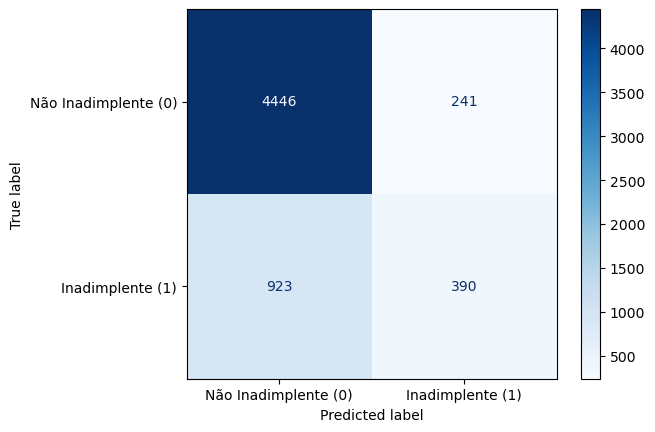

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Relatório completo
print(classification_report(y_test, y_pred_test))

#Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_test)
print("Matriz de Confusão:\n", cm)

#Gráfico da Matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Não Inadimplente (0)", "Inadimplente (1)"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [23]:
#Teste do modelo com exemplo imputado pelo usuário, para verificação de encaixe no perfil de inadimplente:
#sexo: 2 (feminino)
#educacao: 2 (universitário)
#estado_civil: 2 (solteiro)
#num_meses_atrasado: 3
#maior_atraso: 4 (maior número de meses em atraso)
#qtd_pagamentos_em_dia: 5
#variacao_fatura: 150.5
#pagamento_total: 4000
#valor_credito: 20000

#Exemplo de cliente com características específicas
cliente_exemplo = [[2, 2, 2, 3, 4, 5, 150.5, 4000, 20000]]

#Previsão se inadimplente
previsao = model.predict(cliente_exemplo)
if previsao[0] == 0:
  print("Cliente se encaixa no perfil de NÃO INADIMPLENTE.\n\n")
else:
  print("Cliente se encaixa no perfil de INADIMPLENTE.\n\n")

Cliente se encaixa no perfil de INADIMPLENTE.




C:\Users\joaov\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [24]:
#Exemplo de cliente com características específicas
cliente_exemplo = [[2, 2, 2, 0, 1, 5, 150.5, 4000, 20000]]

#Previsão se inadimplente
previsao = model.predict(cliente_exemplo)
if previsao[0] == 0:
  print("Cliente se encaixa no perfil de NÃO INADIMPLENTE.\n\n")
else:
  print("Cliente se encaixa no perfil de INADIMPLENTE.\n\n")

Cliente se encaixa no perfil de NÃO INADIMPLENTE.




C:\Users\joaov\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [25]:
#Exportar modelo criado
import joblib
joblib.dump(model, 'detectaInadimplencia.pkl')

['detectaInadimplencia.pkl']